In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import sys
import importlib

In [2]:
df = pd.read_csv("C:/Users/arine/alzheimer-mri-progression/data/processed/master_labels.csv")
print(df.head())

         PTID DIAGNOSIS  label VISCODE    EXAMDATE PTGENDER  PTEDUCAT  \
0  011_S_0003  Dementia      2      bl  2005-09-30     Male      18.0   
1  011_S_0005        CN      0      bl  2005-09-30     Male      16.0   
2  100_S_0015        CN      0      bl  2005-10-18     Male      18.0   
3  023_S_0030       MCI      1      bl  2005-10-20   Female      19.0   
4  023_S_0031        CN      0      bl  2005-10-24   Female      18.0   

                 PTETHCAT PTRACCAT  MMSCORE  CDRSB  \
0  Not Hispanic or Latino    White     20.0    4.5   
1  Not Hispanic or Latino    White     29.0    0.0   
2  Not Hispanic or Latino    White     29.0    0.0   
3  Not Hispanic or Latino    White     29.0    1.0   
4  Not Hispanic or Latino    White     30.0    0.0   

                                            filepath  
0  C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1....  
1  C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1....  
2  C:\Users\arine\Downloads\ADNI1_Complete_1Yr_1....  
3  C:\Users\arin

In [3]:
train_val, test = train_test_split (
    df,
    test_size = 0.15,                # size of test
    stratify = df['DIAGNOSIS'],      # keeps class balance
    random_state = 10                # makes split reproducible
)

train, val = train_test_split (
    train_val,
    test_size = 0.1765,
    stratify = train_val['DIAGNOSIS'],
    random_state = 10
)

print("Train shape:", train.shape)
print("Validate shape:", val.shape)
print("Test shape:", test.shape)

print("Train distribution:")
print(train['DIAGNOSIS'].value_counts())

print("\nVal distribution:")
print(val['DIAGNOSIS'].value_counts())

print("\nTest distribution:")
print(test['DIAGNOSIS'].value_counts())

train.to_csv('../data/processed/train.csv', index=False)
print(f"\nTrain split CSV saved.")
val.to_csv('../data/processed/val.csv', index=False)
print(f"Validate split CSV saved.")
test.to_csv('../data/processed/test.csv', index=False)
print(f"Test split CSV saved.")

Train shape: (391, 12)
Validate shape: (84, 12)
Test shape: (84, 12)
Train distribution:
DIAGNOSIS
MCI         160
CN          136
Dementia     95
Name: count, dtype: int64

Val distribution:
DIAGNOSIS
MCI         34
CN          30
Dementia    20
Name: count, dtype: int64

Test distribution:
DIAGNOSIS
MCI         35
CN          29
Dementia    20
Name: count, dtype: int64

Train split CSV saved.
Validate split CSV saved.
Test split CSV saved.


In [4]:
sys.path.append('../src')

from dataset import ADNIDataset
from transforms import get_train_transforms, get_val_transforms

from torch.utils.data import DataLoader

In [5]:
train_dataset = ADNIDataset(train, transform=get_train_transforms())
val_dataset = ADNIDataset(val, transform=get_val_transforms())

In [6]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [7]:
images, labels = next(iter(train_loader))
print(f"Image shape: {images.shape}")
print(f"Labels: {labels.shape}")
print(f"Min value: {images.min():.3f}")
print(f"Max value: {images.max():.3f}")

Image shape: torch.Size([4, 1, 128, 128, 128])
Labels: torch.Size([4])
Min value: -1.453
Max value: 6.168


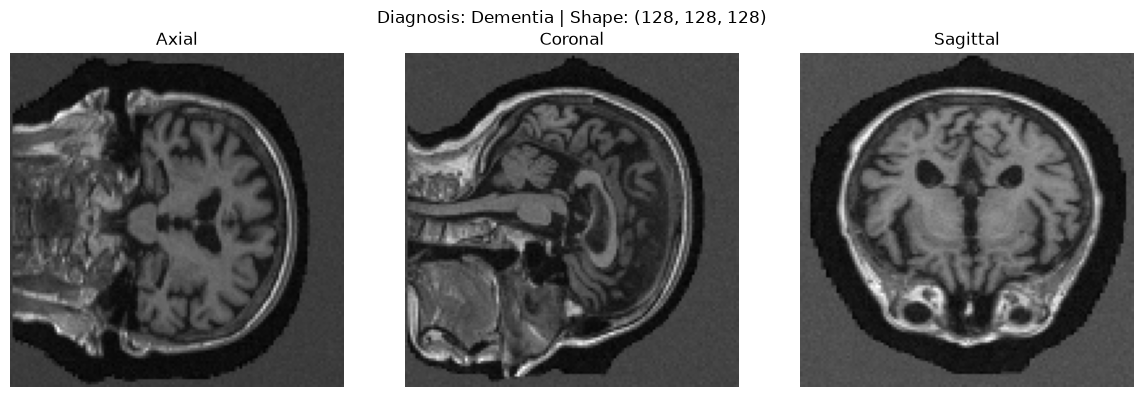

In [8]:
import matplotlib.pyplot as plt

# Load one sample
vol, label = train_dataset[0]
data = vol.squeeze().numpy()  # remove channel dim → (96, 96, 96)

label_names = {0: 'CN', 1: 'MCI', 2: 'Dementia'}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(data[data.shape[0]//2, :, :], cmap='gray')
axes[0].set_title('Axial')
axes[0].axis('off')

axes[1].imshow(data[:, data.shape[1]//2, :], cmap='gray')
axes[1].set_title('Coronal')
axes[1].axis('off')

axes[2].imshow(data[:, :, data.shape[2]//2], cmap='gray')
axes[2].set_title('Sagittal')
axes[2].axis('off')

plt.suptitle(f"Diagnosis: {label_names[label]} | Shape: {data.shape}")
plt.tight_layout()
plt.show()

In [10]:
import torch
import os
from tqdm import tqdm

save_dataset = ADNIDataset(df, transform=get_val_transforms())

for idx in tqdm(range(len(df))):
    volume, label = save_dataset[idx]
    ptid = df.iloc[idx]['PTID']

    torch.save(
        {'volume': volume, 'label':label, 'ptid': ptid},
        f'../data/processed/tensors/{ptid}.pt'
    )

print(f"Saved {len(save_dataset)} tensors")

100%|██████████| 559/559 [03:03<00:00,  3.04it/s]

Saved 559 tensors
